In [1]:
import os, random, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm

import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

def seed_all(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
seed_all()


✅ Using device: cpu


In [2]:
# Kaggle automatically mounts added datasets under /kaggle/input
base_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray"
train_dir, val_dir, test_dir = [os.path.join(base_dir, x) for x in ("train","val","test")]

IMG_SIZE, BATCH = 224, 16
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir, transform=val_tfms)
test_ds  = datasets.ImageFolder(test_dir, transform=val_tfms)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=2)

print(f"✅ Classes: {train_ds.classes}")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")


✅ Classes: ['NORMAL', 'PNEUMONIA']
Train: 5216, Val: 16, Test: 624


In [7]:
class BayesianResNet(nn.Module):
    def __init__(self, n_classes=2, dropout_p=0.5):
        super().__init__()
        # ❌ Remove pretrained weights (Kaggle has no internet)
        # ✅ Use random initialization instead
        self.base = models.resnet18(weights=None)
        in_f = self.base.fc.in_features
        self.base.fc = nn.Identity()
        self.drop1 = nn.Dropout(p=dropout_p)
        self.fc1 = nn.Linear(in_f, 256)
        self.drop2 = nn.Dropout(p=dropout_p)
        self.out = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.base(x)
        x = self.drop1(x)
        x = F.relu(self.fc1(x))
        x = self.drop2(x)
        return self.out(x)

# Initialize model
model = BayesianResNet(n_classes=len(train_ds.classes), dropout_p=0.5).to(device)
print("✅ Bayesian ResNet18 initialized (no pretrained weights).")


✅ Bayesian ResNet18 initialized (no pretrained weights).


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2, factor=0.5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds, labels = 0, [], []
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            out = model(x)
            loss = criterion(out, y)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(y.cpu().numpy())
    return total_loss / len(loader.dataset), accuracy_score(labels, preds)


In [13]:
best_val = 0.0

for epoch in range(1, 6):   # increase epochs if GPU allows
    tr_loss, tr_acc = run_epoch(train_dl, train=True)
    val_loss, val_acc = run_epoch(val_dl, train=False)
    scheduler.step(val_acc)
    print(f"Epoch {epoch}: Train Acc={tr_acc:.3f}, Val Acc={val_acc:.3f}")

    # save the best performing model
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "/kaggle/working/bayes_resnet.pth")
        print("💾 Saved best model.")


Epoch 1: Train Acc=0.907, Val Acc=0.875
💾 Saved best model.


Epoch 2: Train Acc=0.947, Val Acc=0.562


Epoch 3: Train Acc=0.956, Val Acc=0.500


Epoch 4: Train Acc=0.962, Val Acc=0.688


Epoch 5: Train Acc=0.965, Val Acc=0.688


In [18]:
def mc_dropout_predict(model, x, n_samples=20):
    model.train()   # keep dropout active for uncertainty
    probs = []
    with torch.no_grad():
        for _ in range(n_samples):
            p = torch.softmax(model(x), dim=1).cpu().numpy()
            probs.append(p)
    probs = np.stack(probs)
    mean_p = probs.mean(0)
    entropy = -np.sum(mean_p * np.log(mean_p + 1e-12), axis=1)
    return mean_p, entropy


In [19]:
# load best model
model.load_state_dict(torch.load("/kaggle/working/bayes_resnet.pth", map_location=device))
model.to(device)

all_preds, all_labels, all_entropy = [], [], []

for x, y in tqdm(test_dl):
    x = x.to(device)
    mean_p, ent = mc_dropout_predict(model, x, n_samples=20)
    all_preds.extend(mean_p.argmax(1))
    all_labels.extend(y.numpy())
    all_entropy.extend(ent)

acc = accuracy_score(all_labels, all_preds)
print(f"✅ Test Accuracy: {acc:.3f}")
print(f"Average Uncertainty (Entropy): {np.mean(all_entropy):.4f}")


100%|██████████| 39/39 [08:56<00:00, 13.76s/it]

✅ Test Accuracy: 0.593
Average Uncertainty (Entropy): 0.2307


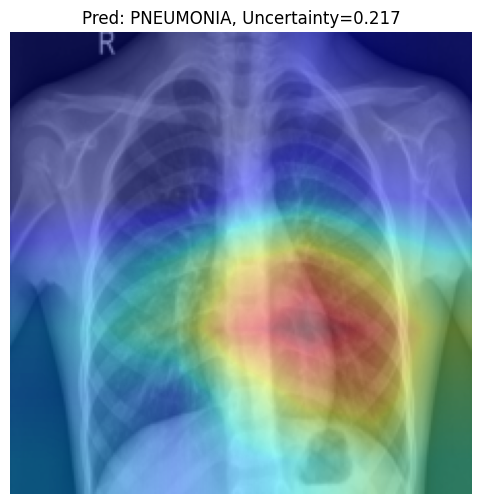

In [24]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ✅ Fully corrected Grad-CAM
def gradcam(model, img_tensor, class_idx=None):
    model.eval()
    feats, grads = None, None
    target_layer = model.base.layer4[-1]

    # Capture activations and gradients from the last convolution block
    def fwd_hook(module, input, output):
        nonlocal feats
        feats = output.detach()

    def bwd_hook(module, grad_in, grad_out):
        nonlocal grads
        grads = grad_out[0].detach()

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_backward_hook(bwd_hook)

    # Forward + backward
    logits = model(img_tensor)
    if class_idx is None:
        class_idx = logits.argmax(1).item()

    loss = logits[0, class_idx]
    model.zero_grad()
    loss.backward()

    # Average gradients across spatial dimensions → channel weights
    weights = grads.mean(dim=(2, 3), keepdim=True)  # (C,1,1)
    # Weighted combination of channels
    grad_cam = torch.sum(weights * feats, dim=1, keepdim=True)  # (N,1,H,W)
    grad_cam = F.relu(grad_cam)
    grad_cam = F.interpolate(
        grad_cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False
    )
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-9)

    h1.remove()
    h2.remove()
    return grad_cam.squeeze().cpu().numpy()

# 🔍 Visualize Grad-CAM
x_batch, y_batch = next(iter(test_dl))
img = x_batch[0:1].to(device)
mean_p, ent = mc_dropout_predict(model, img, n_samples=30)
cls = mean_p.argmax(1)[0]
heat = gradcam(model, img, cls)

# Denormalize image for display
base = (x_batch[0].permute(1, 2, 0).numpy() * 0.224 + 0.456).clip(0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(base)
plt.imshow(heat, cmap="jet", alpha=0.4)
plt.title(f"Pred: {train_ds.classes[cls]}, Uncertainty={ent[0]:.3f}")
plt.axis("off")
plt.show()


In [25]:
import pandas as pd

df = pd.DataFrame({
    "label": all_labels,
    "pred": all_preds,
    "entropy": all_entropy
})
df.to_csv("/kaggle/working/test_predictions_with_uncertainty.csv", index=False)
print("📁 Saved → /kaggle/working/test_predictions_with_uncertainty.csv")


📁 Saved → /kaggle/working/test_predictions_with_uncertainty.csv
